In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
# Load data
df = yf.download("AAPL", start="2015-01-01", end="2024-12-31")

[*********************100%***********************]  1 of 1 completed


In [3]:
# Reset index 
df.reset_index(inplace=True)

In [4]:
# Set Date as index 
df.set_index('Date', inplace=True)

df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.214891,24.682224,23.776352,24.671149,212818400
2015-01-05,23.532719,24.064282,23.346673,23.984547,257142000
2015-01-06,23.534945,23.794081,23.173924,23.596960,263188400
2015-01-07,23.864950,23.964618,23.632391,23.743133,160423600
2015-01-08,24.781893,24.839479,24.075357,24.192745,237458000


## Basic EDA

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2515 entries, 2015-01-02 to 2024-12-30
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   2515 non-null   float64
 1   (High, AAPL)    2515 non-null   float64
 2   (Low, AAPL)     2515 non-null   float64
 3   (Open, AAPL)    2515 non-null   float64
 4   (Volume, AAPL)  2515 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 117.9 KB


In [6]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,2515.000000,2515.000000,2515.000000,2515.000000,2.515000e+03
mean,93.709447,94.619333,92.696716,93.621869,1.171162e+08
std,65.319702,65.911526,64.632731,65.237460,6.839222e+07
min,20.584816,20.887872,20.386579,20.507347,2.323470e+07
25%,35.170424,35.573698,34.811615,35.201302,7.108655e+07
50%,64.313591,64.662671,63.505616,64.072101,1.003845e+08
75%,150.079285,151.805310,148.065288,149.861802,1.426222e+08
max,257.612732,258.686881,256.230300,256.787255,6.488252e+08


In [7]:
df.isnull().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

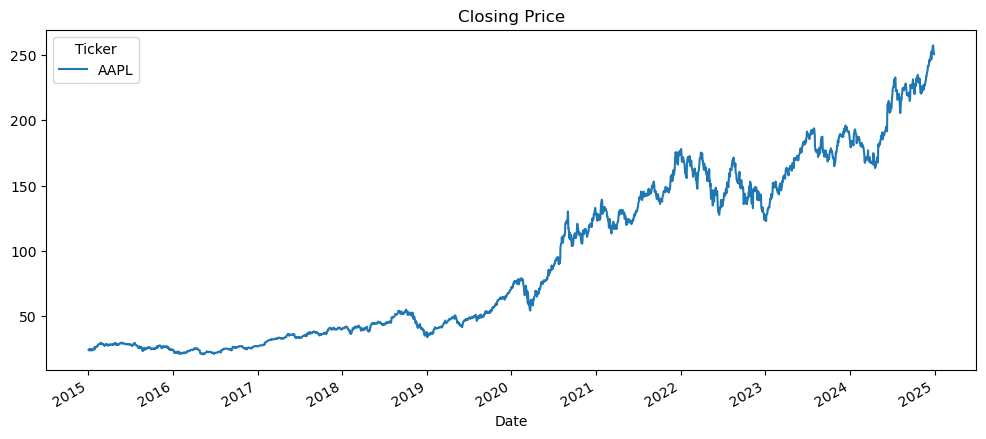

In [8]:
df['Close'].plot(figsize=(12,5), title="Closing Price")
plt.show()

## Resampling (Yearly Min)

In [11]:
df.resample(rule='A').min()

C:\Users\MAYANK SHARMA\AppData\Local\Temp\ipykernel_9888\2153198699.py:1: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  df.resample(rule='A').min()


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-12-31,23.129618,23.794081,20.635423,21.279159,52185600
2016-12-31,20.584816,20.887872,20.386579,20.507347,45903600
2017-12-31,26.715916,26.787300,26.425776,26.665257,56106800
2018-12-31,34.870007,35.990939,34.813009,35.183486,50055600
2019-12-31,33.768089,34.606413,33.722966,34.193187,45448000
2020-12-31,54.213608,55.211524,51.372088,55.110042,46691300
2021-12-31,113.334145,117.269064,113.188044,115.934688,41000000
2022-12-31,124.050720,127.899014,123.883405,125.969942,35195900


## Resampling (Yearly Max)

In [12]:
df.resample(rule='A').max()

C:\Users\MAYANK SHARMA\AppData\Local\Temp\ipykernel_9888\1351435405.py:1: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  df.resample(rule='A').max()


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-12-31,29.594498,29.916112,29.339950,29.898326,648825200
2016-12-31,27.090334,27.191136,26.907053,27.074293,533478800
2017-12-31,41.277504,41.460003,40.912507,40.971006,447940000
2018-12-31,54.921658,55.252980,54.379704,54.616345,384986800
2019-12-31,70.785454,70.862581,69.789900,70.175576,365248800
2020-12-31,132.936813,134.979174,130.651363,134.259502,426510000
2021-12-31,176.459732,178.221071,174.698364,177.232738,195432700
2022-12-31,178.103668,179.013714,175.275693,178.710370,182602000


## Plot Yearly Max (Closing Price)

C:\Users\MAYANK SHARMA\AppData\Local\Temp\ipykernel_9888\895980766.py:1: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  df.resample(rule='A').max()['Close'].plot()


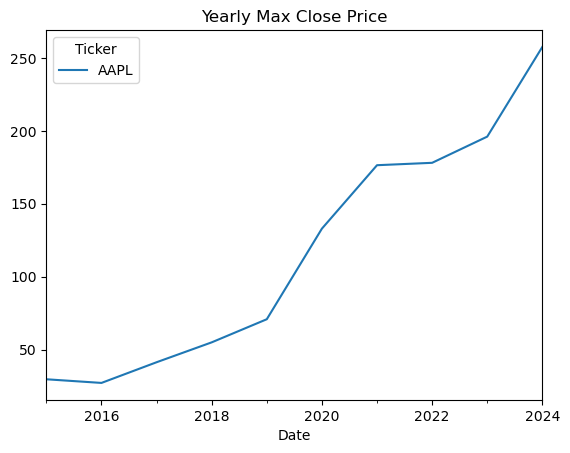

In [13]:
df.resample(rule='A').max()['Close'].plot()
plt.title("Yearly Max Close Price")
plt.show()

## Quarterly Start ('QS')

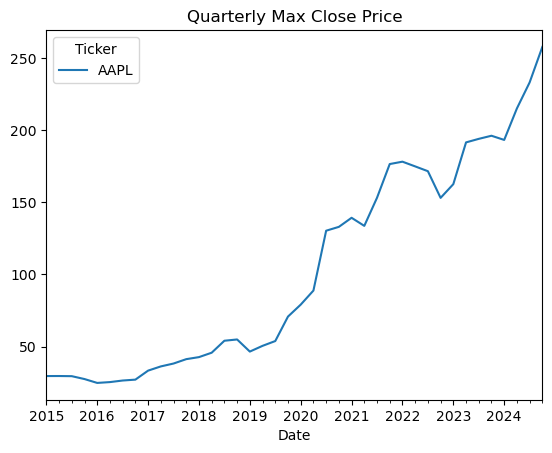

In [14]:
df.resample(rule='QS').max()['Close'].plot()
plt.title("Quarterly Max Close Price")
plt.show()

## Business Year End ('BA')

In [15]:
df.resample(rule='BA').max()

C:\Users\MAYANK SHARMA\AppData\Local\Temp\ipykernel_9888\2586250062.py:1: FutureWarning: 'BA' is deprecated and will be removed in a future version, please use 'BYE' instead.
  df.resample(rule='BA').max()


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-12-31,29.594498,29.916112,29.339950,29.898326,648825200
2016-12-30,27.090334,27.191136,26.907053,27.074293,533478800
2017-12-29,41.277504,41.460003,40.912507,40.971006,447940000
2018-12-31,54.921658,55.252980,54.379704,54.616345,384986800
2019-12-31,70.785454,70.862581,69.789900,70.175576,365248800
2020-12-31,132.936813,134.979174,130.651363,134.259502,426510000
2021-12-31,176.459732,178.221071,174.698364,177.232738,195432700
2022-12-30,178.103668,179.013714,175.275693,178.710370,182602000


## Business Quarter Start ('BQS') 

In [16]:
df.resample(rule='BQS').max()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-01,29.573689,29.707096,29.166764,29.560339,585908400
2015-04-01,29.594498,29.916112,29.339950,29.898326,475696000
2015-07-01,29.489561,29.690518,29.183655,29.663729,648825200
2015-10-01,27.492207,27.772585,27.279130,27.617819,385813200
2016-01-01,24.813200,25.007973,24.659190,24.849434,533478800
2016-04-01,25.388462,25.454142,25.214073,25.390728,458408400
2016-07-01,26.476368,26.616113,26.125856,26.389311,443554800
2016-10-03,27.090334,27.191136,26.907053,27.074293,264536800


## Bar Plot Resampling 

C:\Users\MAYANK SHARMA\AppData\Local\Temp\ipykernel_9888\3433599681.py:1: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  df['Close'].resample(rule='A').mean().plot(kind='bar')


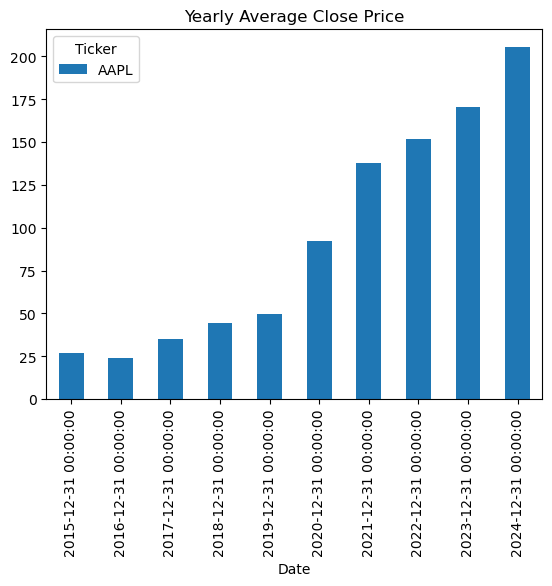

In [17]:
df['Close'].resample(rule='A').mean().plot(kind='bar')
plt.title("Yearly Average Close Price")
plt.show()

## Monthly Max

C:\Users\MAYANK SHARMA\AppData\Local\Temp\ipykernel_9888\1597037436.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df['Close'].resample(rule='M').max().plot(kind='bar', figsize=(15,6))


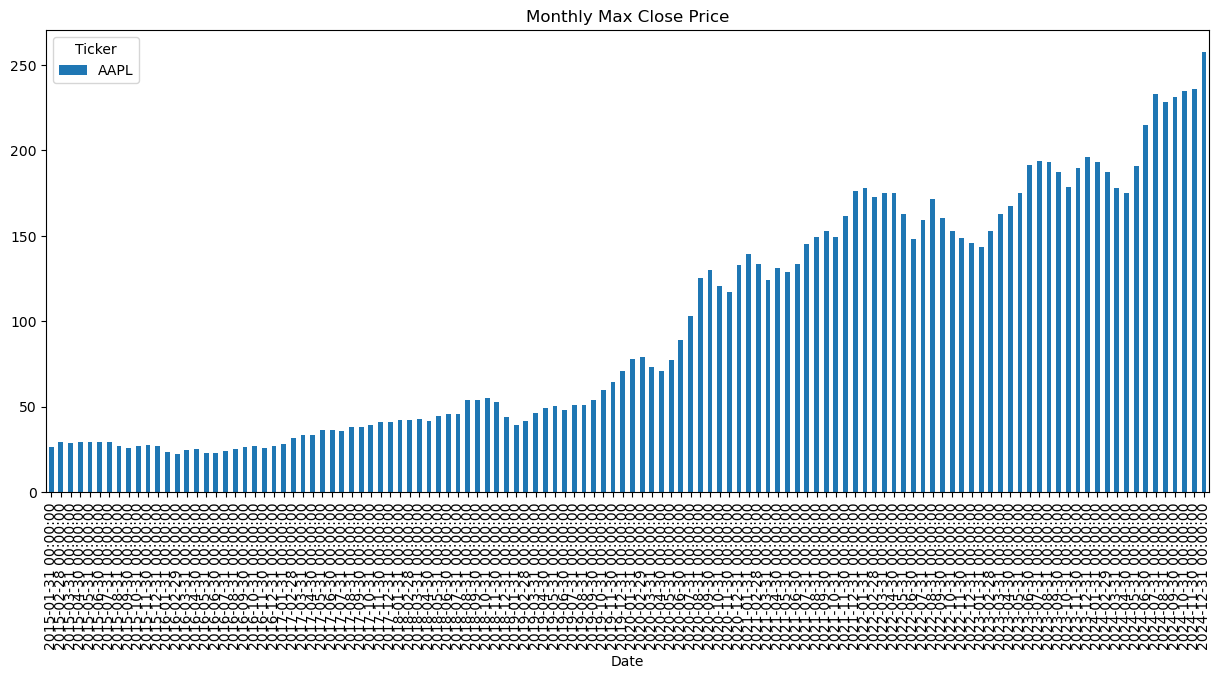

In [18]:
df['Close'].resample(rule='M').max().plot(kind='bar', figsize=(15,6))
plt.title("Monthly Max Close Price")
plt.show()

## Rolling Mean (Moving Average)

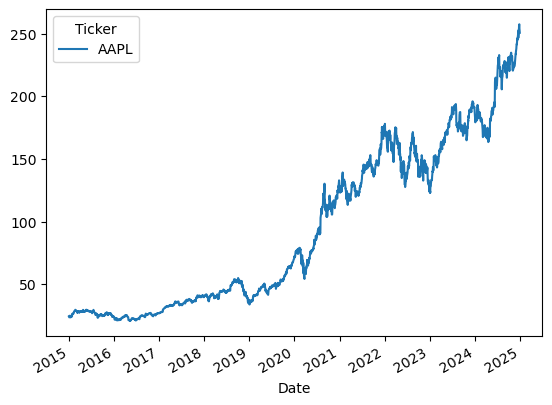

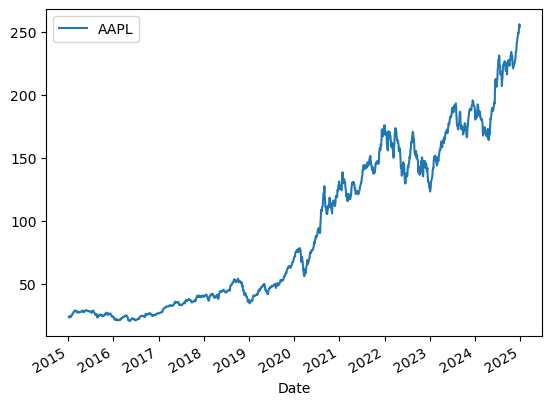

In [19]:
A = df['Close'].rolling(3).mean()

df['Close'].plot(label='Original')
A.plot(label='Rolling Mean (3)')
plt.legend()
plt.show()

## Daily Returns 

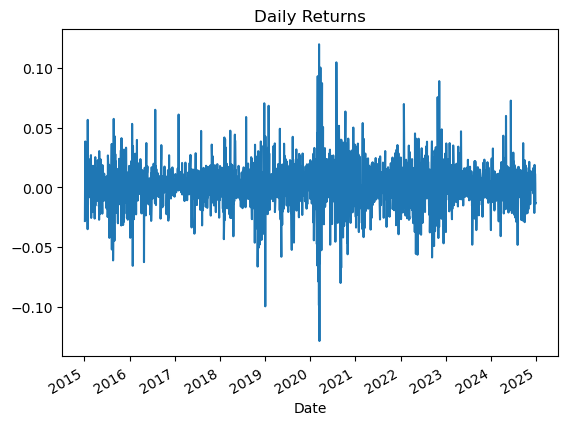

In [20]:
df['Returns'] = df['Close'].pct_change()

df['Returns'].plot(title="Daily Returns")
plt.show()

## Stationary Test (ADF Test)

In [28]:
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

In [29]:
# Ho: It is non-stationary
# H1: It is stationary

def adfuller_test(series):
    result = adfuller(series.dropna())
    
    labels = ['ADF Test Statistic','p-value','#Lags Used','Number of Observations Used']
    
    for value,label in zip(result,labels):
        print(label+' : '+str(value))
    
    print("\nCritical Values:")
    for key,val in result[4].items():
        print(key+' : '+str(val))
    
    if result[1] <= 0.05:
        print("\nReject Ho → Data is STATIONARY ✅")
    else:
        print("\nFail to reject Ho → Data is NON-STATIONARY ❌")

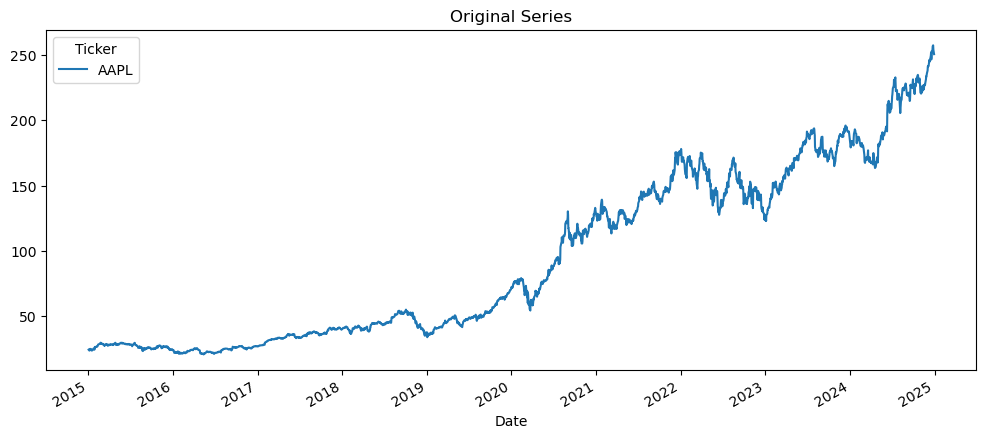

ADF Test Statistic : 0.8448226631517772
p-value : 0.9923262974095125
#Lags Used : 0
Number of Observations Used : 2514

Critical Values:
1% : -3.4329538144697187
5% : -2.8626903542179405
10% : -2.567382377622466

Fail to reject Ho → Data is NON-STATIONARY ❌


In [30]:
df['Close'].plot(figsize=(12,5), title="Original Series")
plt.show()

adfuller_test(df['Close'])

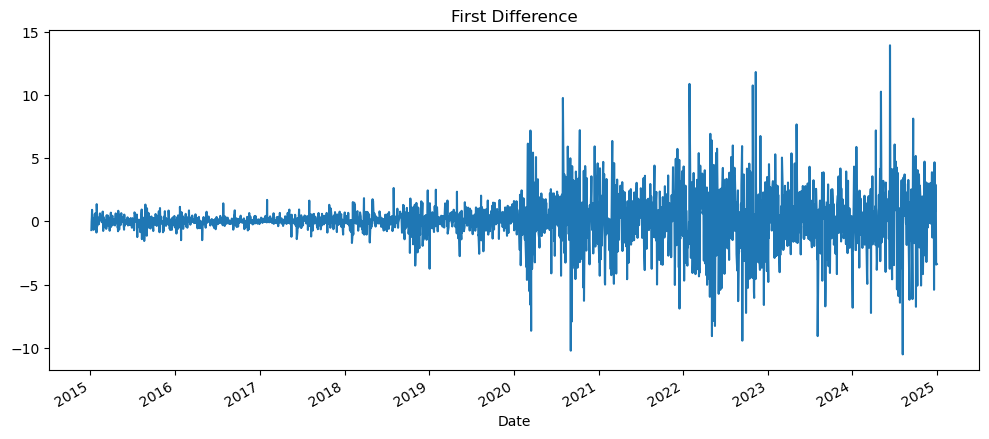

ADF Test Statistic : -16.17873808739881
p-value : 4.288601447004246e-29
#Lags Used : 8
Number of Observations Used : 2505

Critical Values:
1% : -3.4329631791044304
5% : -2.8626944896608433
10% : -2.5673845793841457

Reject Ho → Data is STATIONARY ✅


In [31]:
df['Close First Difference'] = df['Close'] - df['Close'].shift(1)

df['Close First Difference'].plot(figsize=(12,5), title="First Difference")
plt.show()

adfuller_test(df['Close First Difference'])

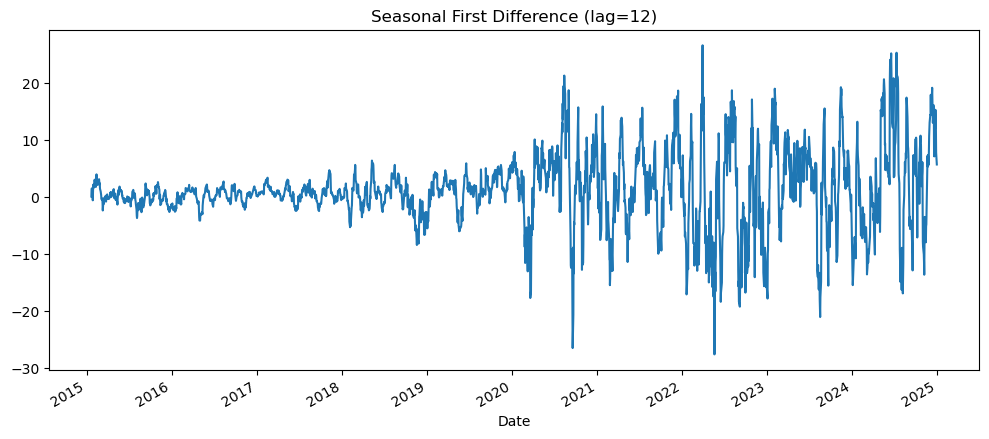

ADF Test Statistic : -7.520755887395109
p-value : 3.7964823280087565e-11
#Lags Used : 27
Number of Observations Used : 2475

Critical Values:
1% : -3.4329948869452735
5% : -2.8627084918155745
10% : -2.5673920343230283

Reject Ho → Data is STATIONARY ✅


In [32]:
df['Seasonal First Difference'] = df['Close'] - df['Close'].shift(12)

df['Seasonal First Difference'].plot(figsize=(12,5), title="Seasonal First Difference (lag=12)")
plt.show()

adfuller_test(df['Seasonal First Difference'])